In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset_detection_2class.zip to dataset_detection_2class.zip


In [ ]:
import zipfile

zip_path = "/content/dataset_detection_2class.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset_detection_2class.zip'

In [ ]:
import os

base_path = "/content/dataset_detection_2class"

print(os.listdir(base_path))

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset_detection_2class'

In [ ]:
print("Train images:", len(os.listdir(base_path + "/train/images")))
print("Valid images:", len(os.listdir(base_path + "/valid/images")))
print("Test images:", len(os.listdir(base_path + "/test/images")))

Train images: 1876
Valid images: 133
Test images: 26


In [ ]:
with open("/content/dataset_detection_2class/data.yaml", "r") as f:
    print(f.read())

path: C:/Users/OM/Downloads/dataset_detection_2class

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: crack
  1: porosity


In [ ]:
yaml_content = """
path: /content/dataset_detection_2class
train: train/images
val: valid/images
test: test/images

nc: 2
names:
  0: crack
  1: porosity
"""

with open("/content/dataset_detection_2class/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml updated successfully!")

data.yaml updated successfully!


In [ ]:
with open("/content/dataset_detection_2class/data.yaml", "r") as f:
    print(f.read())


path: /content/dataset_detection_2class
train: train/images
val: valid/images
test: test/images

nc: 2
names:
  0: crack
  1: porosity



In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 9.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8n loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLOv8n loaded successfully!


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.val(
    data="/content/dataset_detection_2class/data.yaml",
    imgsz=320,
    batch=16,
    device=0
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1062.3±548.8 MB/s, size: 47.1 KB)
val: Scanning /content/dataset_detection_2class/valid/labels... 133 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 133/133 1.4Kit/s 0.1s
val: New cache created: /content/dataset_detection_2class/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 3.5it/s 2.5s
                   all        133        619    0.00719    0.00588   0.000495   0.000216
                person         71         85     0.0144     0.0118    0.00099   0.000431
               bicycle         62        534          0          0          0          0
Speed: 0.4ms preprocess, 2.8ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/dataset_detection_2class/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    workers=2,
    device=0
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_detection_2class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=N

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

test_results = model.val(
    data="/content/dataset_detection_2class/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0
)

In [ ]:
predictions = model.predict(
    source="/content/dataset_detection_2class/test/images",
    imgsz=640,
    conf=0.25,
    device=0,
    save=True
)

print("Test predictions completed!")

Prediction images: 26


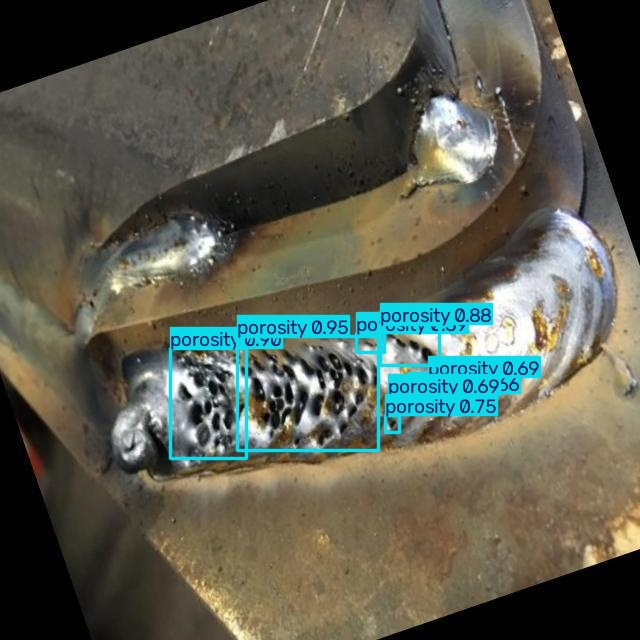

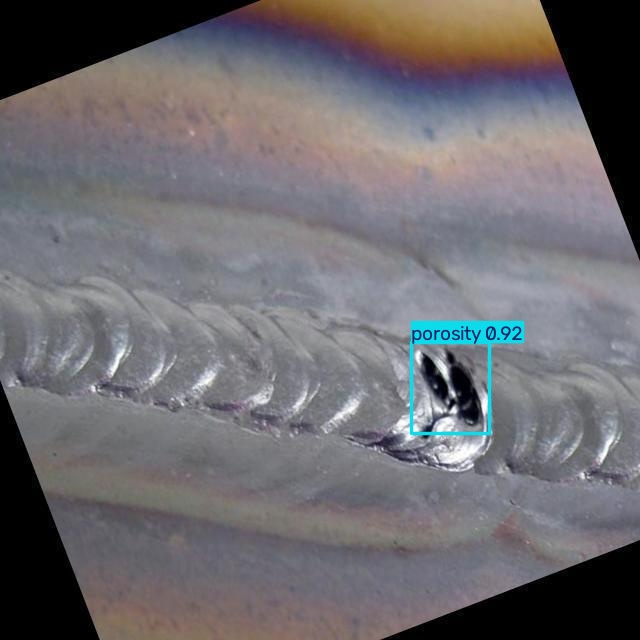

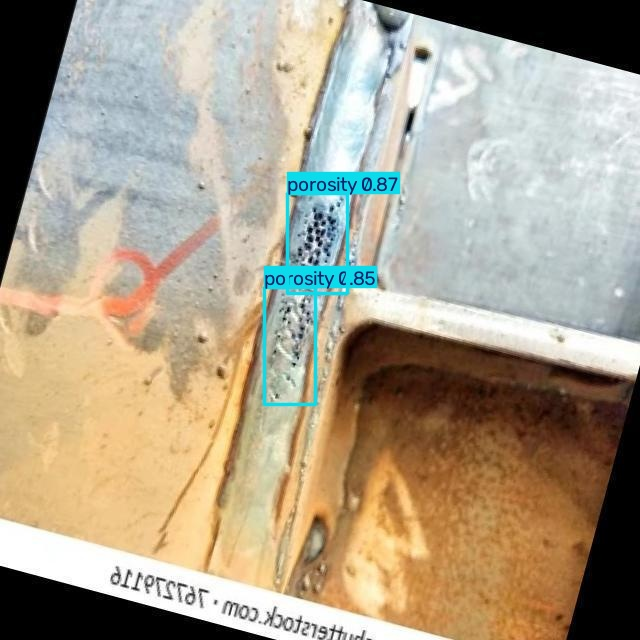

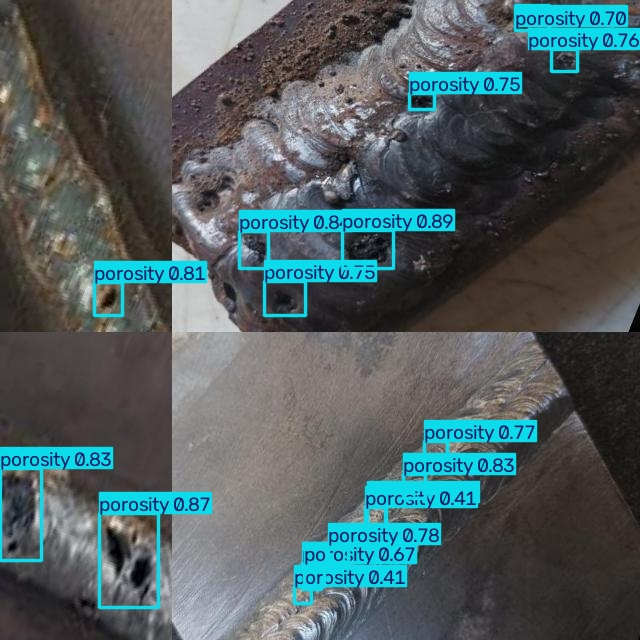

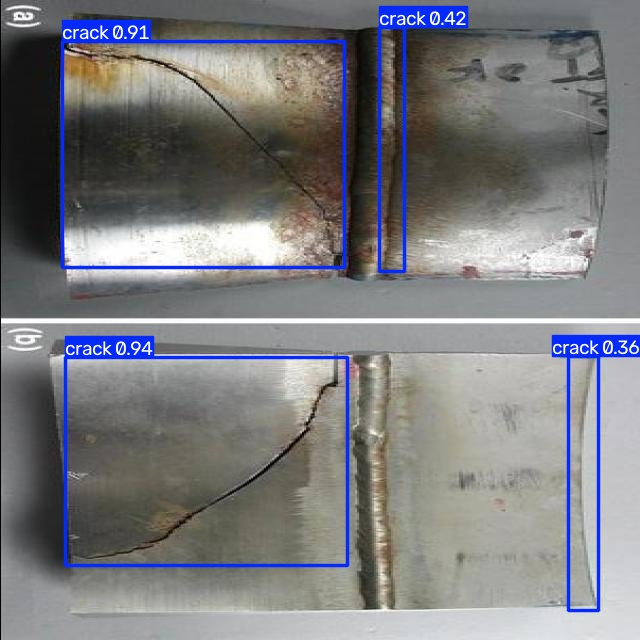

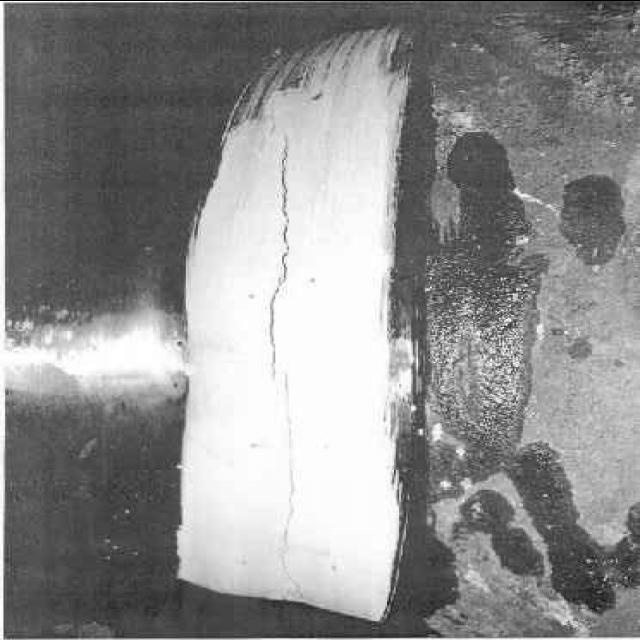

In [ ]:
from IPython.display import display
from PIL import Image
import os

pred_dir = "/content/runs/detect/predict-2"

images = [
    f for f in os.listdir(pred_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Prediction images:", len(images))

for name in images[:6]:
    img = Image.open(os.path.join(pred_dir, name))
    display(img)

In [ ]:
import os

model_path = "/content/runs/detect/train/weights/best.pt"

print("Model exists:", os.path.exists(model_path))

Model exists: True


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 9.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving best.pt to best.pt


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving data.yaml to data.yaml


In [ ]:
data_yaml_path = "/content/data.yaml"

print("Using:", data_yaml_path)

Using: /content/data.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

results = model.val(
    data="/content/data.yaml",
    split="test",
    imgsz=640,
    batch=16
)

print("Precision:", results.box.mp)
print("Recall:", results.box.mr)
print("mAP50:", results.box.map50)
print("mAP50-95:", results.box.map)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs



FileNotFoundError: Dataset '/content/data.yaml' images not found, missing path '/content/datasets/C:/Users/OM/Downloads/dataset_detection_2class/test/images'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

In [ ]:
results = model.val(
    data="/content/dataset_detection_2class/data.yaml",
    split="test",
    imgsz=640,
    batch=16
)

print("Precision:", results.box.mp)
print("Recall:", results.box.mr)
print("mAP50:", results.box.map50)
print("mAP50-95:", results.box.map)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


FileNotFoundError: '/content/dataset_detection_2class/data.yaml' does not exist

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "data.yaml" in files:
        print(os.path.join(root, "data.yaml"))

In [ ]:
from google.colab import files

uploaded_image = files.upload()

Saving IMG_20230131_114028_jpg.rf.94601a1fdfa0e1df578dd69d965a1c43.jpg to IMG_20230131_114028_jpg.rf.94601a1fdfa0e1df578dd69d965a1c43.jpg



image 1/1 /content/IMG_20230131_114028_jpg.rf.94601a1fdfa0e1df578dd69d965a1c43.jpg: 640x640 2 cracks, 412.3ms
Speed: 56.4ms preprocess, 412.3ms inference, 34.7ms postprocess per image at shape (1, 3, 640, 640)


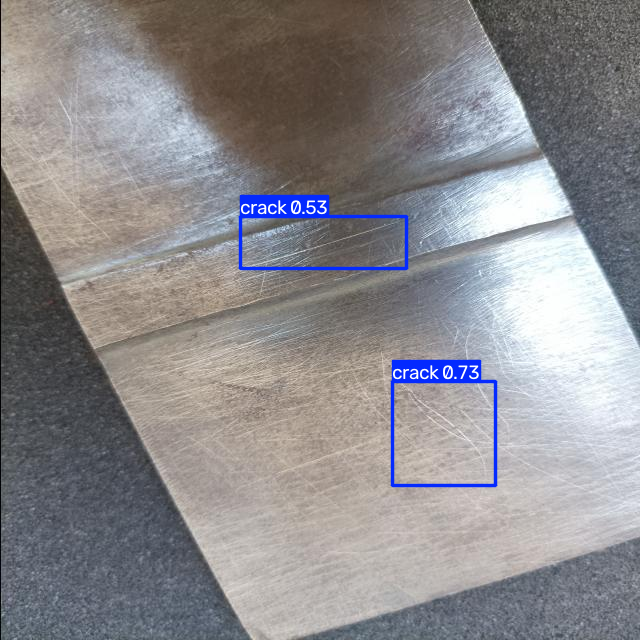

In [ ]:
image_path = "/content/" + list(uploaded_image.keys())[0]

results = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    device="cpu"
)

results[0].show()


In [ ]:
from google.colab import files

uploaded_image = files.upload()

Saving IMG_20230131_185619_jpg.rf.fb87b149d97e426a77bd06ee9e322ed3.jpg to IMG_20230131_185619_jpg.rf.fb87b149d97e426a77bd06ee9e322ed3.jpg



image 1/1 /content/IMG_20230131_185619_jpg.rf.fb87b149d97e426a77bd06ee9e322ed3.jpg: 640x640 1 crack, 244.2ms
Speed: 8.6ms preprocess, 244.2ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)


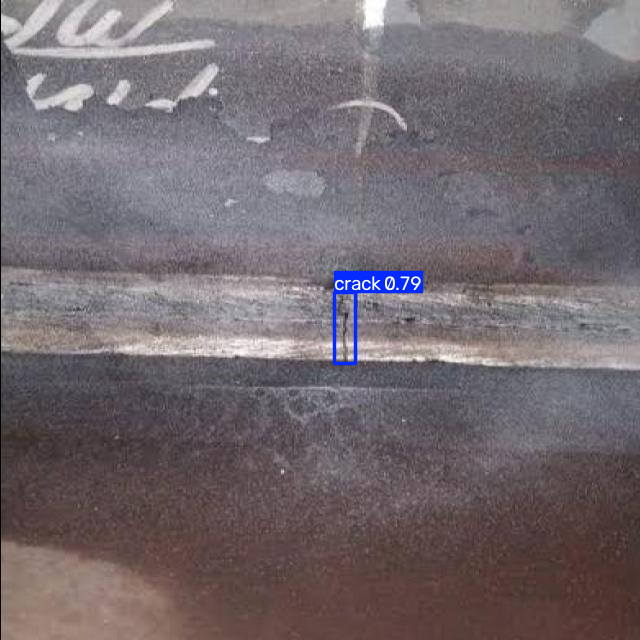

In [ ]:
image_path = "/content/" + list(uploaded_image.keys())[0]

results = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    device="cpu"
)

results[0].show()


In [ ]:
from google.colab import files

uploaded_image = files.upload()

Saving IMG_20230131_114504_jpg.rf.b4c79aaec2b03eb77c66f0b17241c7f4.jpg to IMG_20230131_114504_jpg.rf.b4c79aaec2b03eb77c66f0b17241c7f4.jpg



image 1/1 /content/IMG_20230131_114504_jpg.rf.b4c79aaec2b03eb77c66f0b17241c7f4.jpg: 640x640 2 porositys, 116.0ms
Speed: 4.6ms preprocess, 116.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


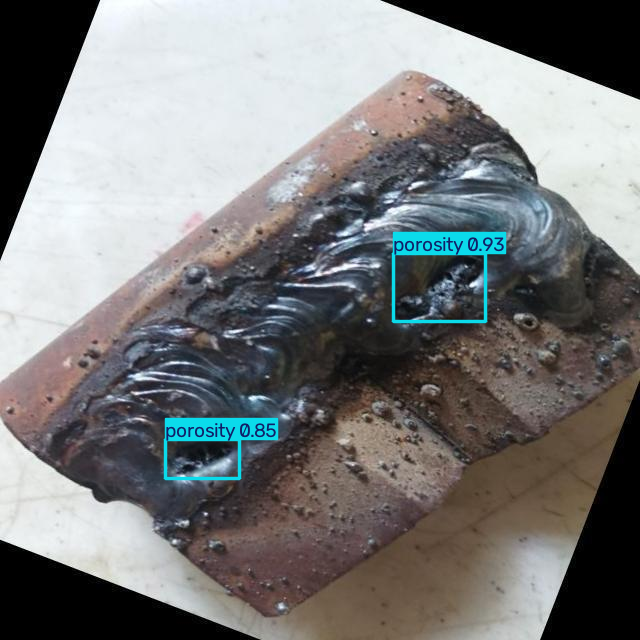

In [ ]:
image_path = "/content/" + list(uploaded_image.keys())[0]

results = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    device="cpu"
)

results[0].show()


###img size 800

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset_detection_2class.zip to dataset_detection_2class.zip


In [ ]:
import zipfile
import os

zip_path = "/content/dataset_detection_2class.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted.")
print(os.listdir("/content/dataset_detection_2class"))

Dataset extracted.
['train', 'valid', 'test', 'data.yaml']


In [ ]:
print(open("/content/dataset_detection_2class/data.yaml").read())

path: C:/Users/OM/Downloads/dataset_detection_2class

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: crack
  1: porosity


In [ ]:
yaml_text = """
path: /content/dataset_detection_2class

train: train/images
val: valid/images
test: test/images

nc: 2
names:
  0: crack
  1: porosity
"""

with open("/content/dataset_detection_2class/data.yaml", "w") as f:
    f.write(yaml_text)

print(open("/content/dataset_detection_2class/data.yaml").read())


path: /content/dataset_detection_2class

train: train/images
val: valid/images
test: test/images

nc: 2
names:
  0: crack
  1: porosity



In [ ]:
import os

base = "/content/dataset_detection_2class"

print("Train images:", len(os.listdir(os.path.join(base, "train/images"))))
print("Valid images:", len(os.listdir(os.path.join(base, "valid/images"))))
print("Test images:", len(os.listdir(os.path.join(base, "test/images"))))

Train images: 1876
Valid images: 133
Test images: 26


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
from ultralytics import YOLO

# Load the same YOLOv8 Nano model
model_800 = YOLO("yolov8n.pt")

# Train with higher image resolution
results_800 = model_800.train(
    data="/content/dataset_detection_2class/data.yaml",
    epochs=50,
    imgsz=800,
    batch=16,
    device=0,
    project="/content/week6_improvement",
    name="yolov8n_800",
    exist_ok=True
)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_detection_2class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_800, nbs=64, nms=None, op

In [ ]:
from ultralytics import YOLO

best_800 = YOLO(
    "/content/week6_improvement/yolov8n_800/weights/best.pt"
)

test_results_800 = best_800.val(
    data="/content/dataset_detection_2class/data.yaml",
    split="test",
    imgsz=800,
    batch=16,
    device=0
)

print("Test Precision:", test_results_800.box.mp)
print("Test Recall:", test_results_800.box.mr)
print("Test mAP50:", test_results_800.box.map50)
print("Test mAP50-95:", test_results_800.box.map)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1116.8±366.2 MB/s, size: 58.5 KB)
val: Scanning /content/dataset_detection_2class/test/labels... 26 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 26/26 386.6it/s 0.1s
val: New cache created: /content/dataset_detection_2class/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0s/it 2.0s
                   all         26        104      0.926      0.765      0.834      0.491
                 crack         14         18      0.928      0.667      0.713       0.38
              porosity         12         86      0.925      0.863      0.956      0.602
Speed: 9.4ms preprocess, 17.1ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/detect/val
Test Precision: 0.92

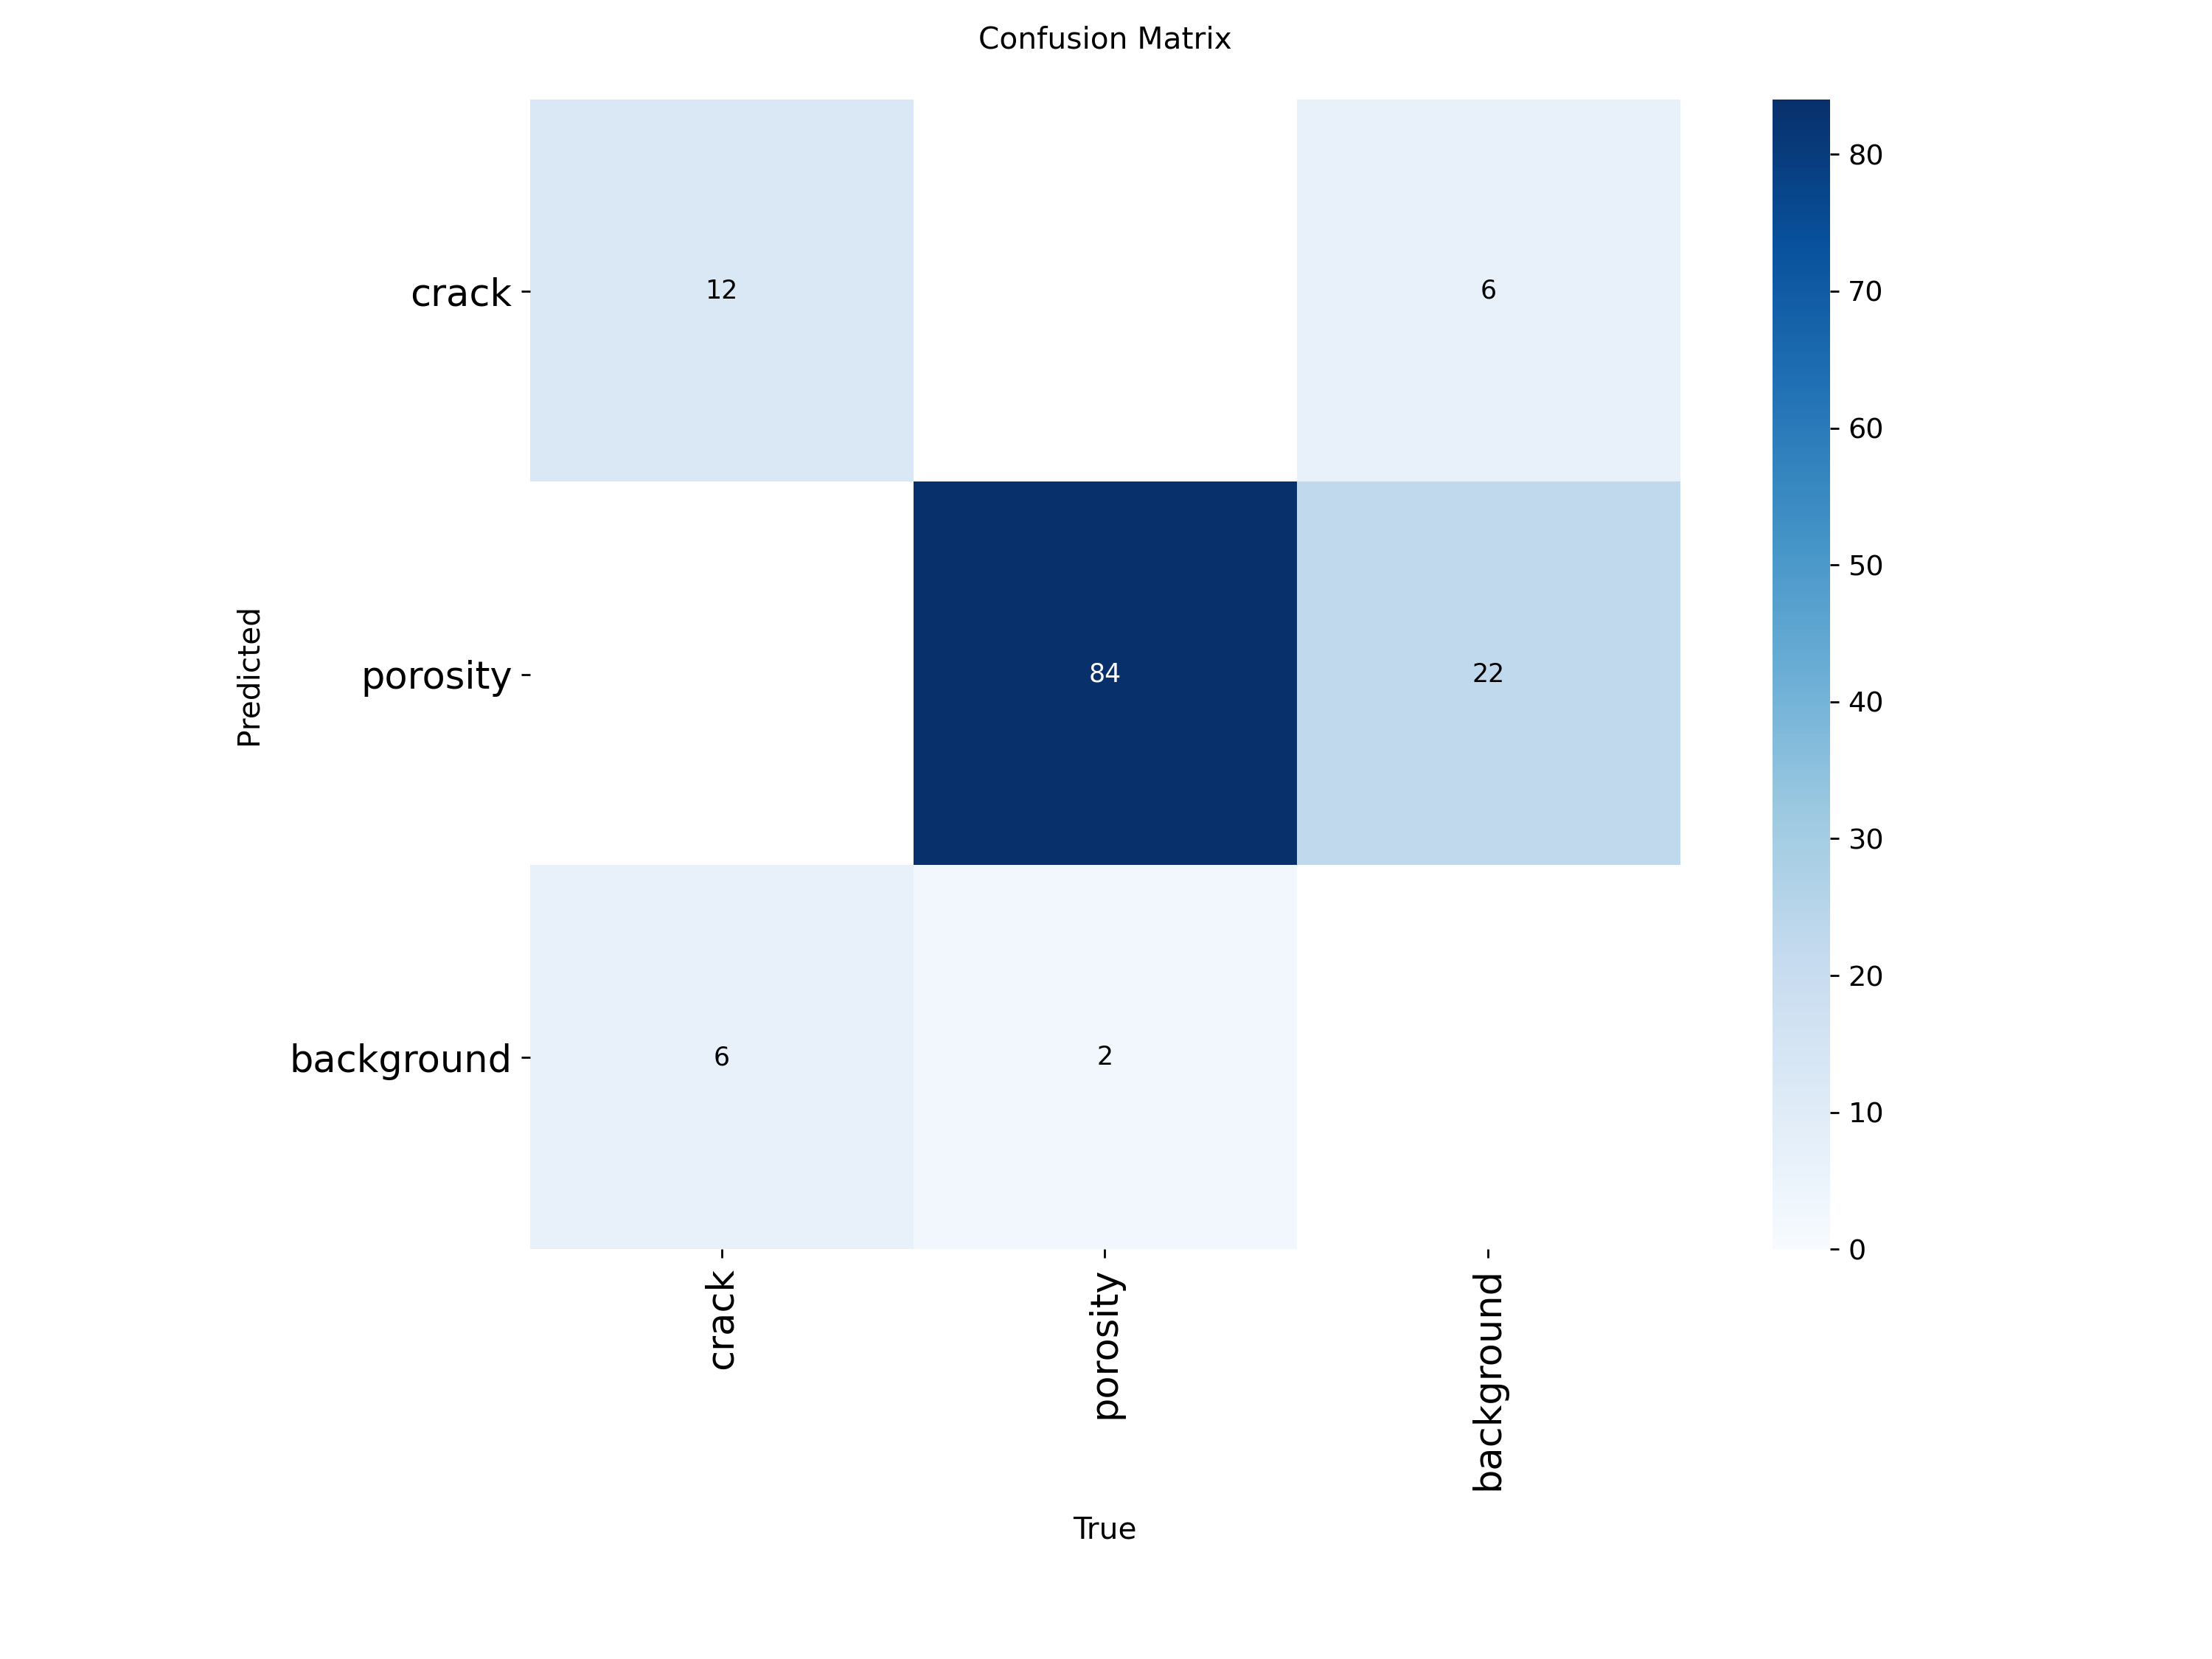

In [ ]:
from IPython.display import Image, display
import os

cm_path = os.path.join(
    str(test_results_800.save_dir),
    "confusion_matrix.png"
)

display(Image(filename=cm_path))

In [ ]:
import os
import shutil

save_dir = "/content/drive/MyDrive/Week6_YOLO_Models"
os.makedirs(save_dir, exist_ok=True)

shutil.copy2(
    "/content/week6_improvement/yolov8n_800/weights/best.pt",
    os.path.join(save_dir, "yolov8n_800_best.pt")
)

print("800 model saved successfully.")
print(os.path.join(save_dir, "yolov8n_800_best.pt"))

800 model saved successfully.
/content/drive/MyDrive/Week6_YOLO_Models/yolov8n_800_best.pt


In [ ]:
from ultralytics import YOLO

model_800 = YOLO(
    "/content/drive/MyDrive/Week6_YOLO_Models/yolov8n_800_best.pt"
)

Saving 20220608_102813_jpg.rf.1b587f360612587b9708aaf1687f46e9.jpg to 20220608_102813_jpg.rf.1b587f360612587b9708aaf1687f46e9.jpg

image 1/1 /content/20220608_102813_jpg.rf.1b587f360612587b9708aaf1687f46e9.jpg: 800x800 2 cracks, 9.6ms
Speed: 2.5ms preprocess, 9.6ms inference, 1.2ms postprocess per image at shape (1, 3, 800, 800)


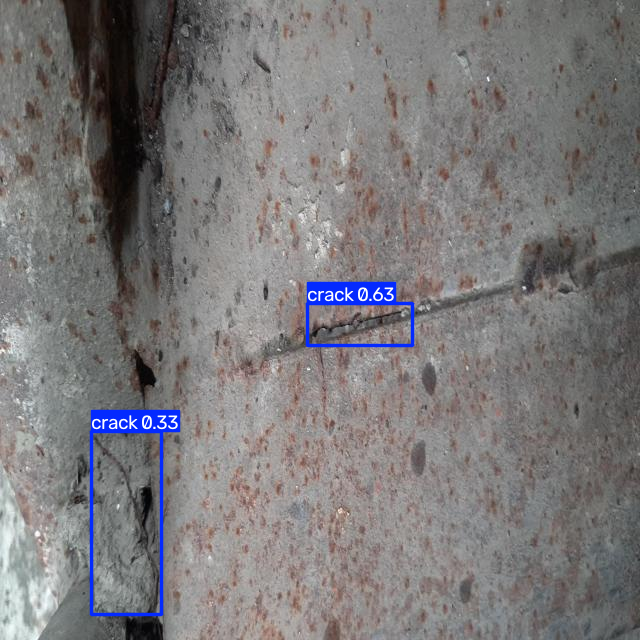

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

# Upload one image
uploaded = files.upload()

image_path = "/content/" + list(uploaded.keys())[0]

# Run prediction
results = model_800.predict(
    source=image_path,
    imgsz=800,
    conf=0.25,
    device=0
)

# Show result
results[0].show()